In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../results/figures")

file_table = pd.read_csv(PROCESSED_DATA_DIR / "file_table.csv")
file_table.head()

,file_name,file_path,study,group,subject_id,subject_number,trial
0,GaCo01_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo01,1,1
1,GaCo02_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo02,2,1
2,GaCo02_02.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo02,2,2
3,GaCo03_01.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo03,3,1
4,GaCo03_02.txt,..\data\raw\gait-in-parkinsons-disease-1.0.0\G...,Ga,Control,GaCo03,3,2


In [3]:
def load_gait_signal(file_path):
    df = pd.read_csv(file_path, sep=r"\s+", header=None)
    
    columns = (
        ["time"]
        + [f"left_sensor_{i}" for i in range(1, 9)]
        + [f"right_sensor_{i}" for i in range(1, 9)]
        + ["left_total_force", "right_total_force"]
    )
    
    if df.shape[1] != len(columns):
        raise ValueError(
            f"{Path(file_path).name} has {df.shape[1]} columns, "
            f"but expected {len(columns)}"
        )
    
    df.columns = columns
    return df

In [4]:
file_table["file_path"] = file_table["file_path"].apply(Path)

control_file = file_table[file_table["group"] == "Control"]["file_path"].iloc[0]
patient_file = file_table[file_table["group"] == "Parkinson"]["file_path"].iloc[0]

control_df = load_gait_signal(control_file)
patient_df = load_gait_signal(patient_file)

control_file.name, patient_file.name

('GaCo01_01.txt', 'GaPt03_01.txt')

In [5]:
control_df.head()

,time,left_sensor_1,left_sensor_2,left_sensor_3,left_sensor_4,left_sensor_5,left_sensor_6,left_sensor_7,left_sensor_8,right_sensor_1,right_sensor_2,right_sensor_3,right_sensor_4,right_sensor_5,right_sensor_6,right_sensor_7,right_sensor_8,left_total_force,right_total_force
0,0.00,199.1,87.34,91.08,24.09,21.12,87.67,87.23,64.57,163.9,79.86,112.42,50.82,13.75,102.74,144.98,79.53,662.20,748.00
1,0.01,199.1,87.34,91.08,24.09,21.12,87.67,87.23,64.57,163.9,79.86,112.42,50.82,13.75,102.74,144.98,79.53,662.20,748.00
2,0.02,199.1,87.34,91.08,24.09,21.12,87.67,87.23,62.59,163.9,79.86,112.42,50.82,13.75,102.74,144.98,79.53,660.22,748.00
3,0.03,199.1,87.34,91.08,24.09,21.12,87.67,89.10,64.57,163.9,77.55,112.42,48.07,13.75,105.49,144.98,79.53,664.07,745.69
4,0.04,199.1,87.34,91.08,24.09,21.12,87.67,87.23,62.59,163.9,77.55,112.42,50.82,13.75,105.49,144.98,79.53,660.22,748.44


In [6]:
def add_foot_contact_columns(df, threshold=20):
    df = df.copy()
    
    df["left_contact"] = df["left_total_force"] > threshold
    df["right_contact"] = df["right_total_force"] > threshold
    
    return df

In [7]:
control_df = add_foot_contact_columns(control_df, threshold=20)
patient_df = add_foot_contact_columns(patient_df, threshold=20)

control_df[["time", "left_total_force", "right_total_force", "left_contact", "right_contact"]].head()

,time,left_total_force,right_total_force,left_contact,right_contact
0,0.00,662.20,748.00,True,True
1,0.01,662.20,748.00,True,True
2,0.02,660.22,748.00,True,True
3,0.03,664.07,745.69,True,True
4,0.04,660.22,748.44,True,True


In [8]:
def plot_contact_detection(df, title, start_time=20, end_time=30):
    zoom_df = df[(df["time"] >= start_time) & (df["time"] <= end_time)]
    
    plt.figure(figsize=(14, 5))
    
    plt.plot(
        zoom_df["time"], 
        zoom_df["left_total_force"], 
        label="Left total force"
    )
    
    plt.plot(
        zoom_df["time"], 
        zoom_df["right_total_force"], 
        label="Right total force"
    )
    
    # show contact periods as small markers near the bottom
    plt.scatter(
        zoom_df["time"], 
        zoom_df["left_contact"] * 50, 
        s=5, 
        label="Left contact detected"
    )
    
    plt.scatter(
        zoom_df["time"], 
        zoom_df["right_contact"] * 100, 
        s=5, 
        label="Right contact detected"
    )
    
    plt.xlabel("Time (s)")
    plt.ylabel("Force (N)")
    plt.title(title)
    plt.legend()
    plt.show()

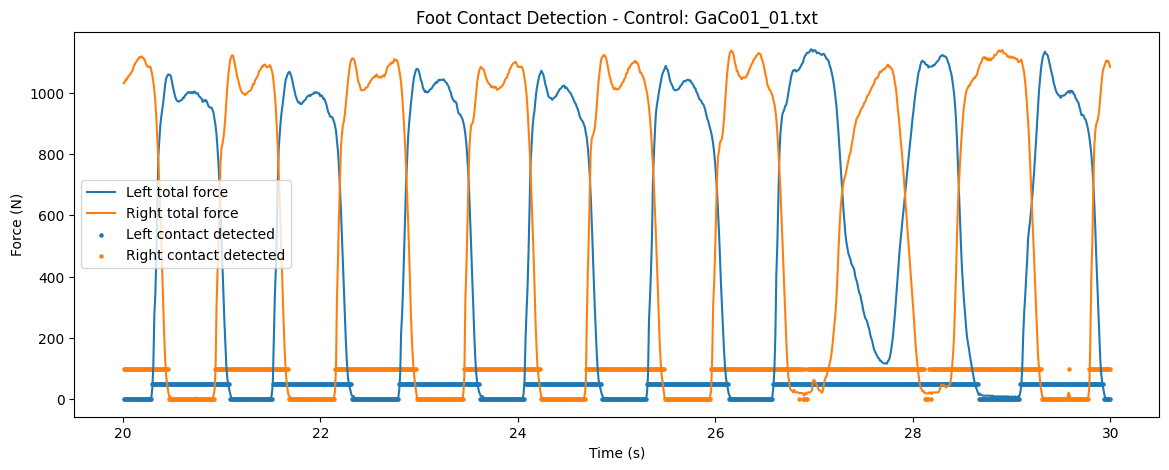

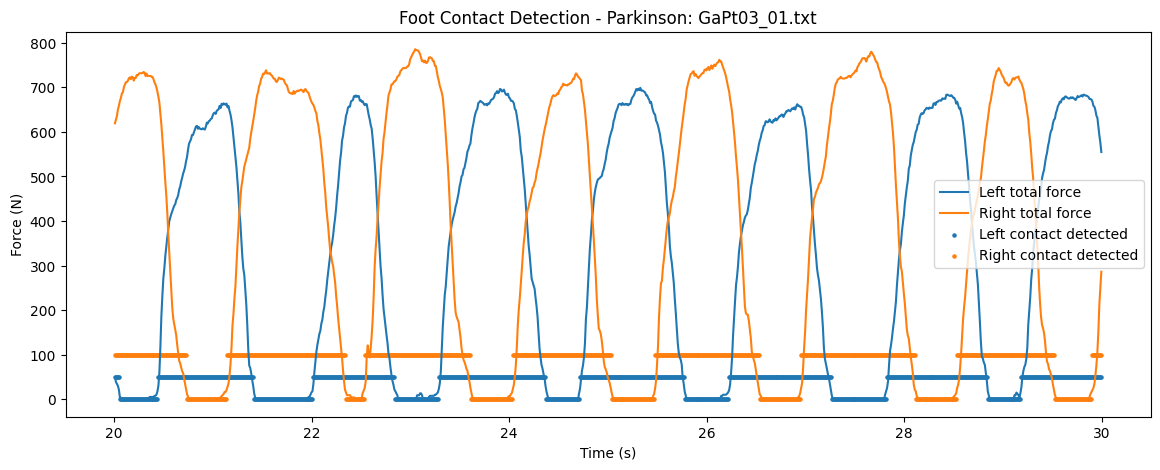

In [9]:
plot_contact_detection(
    control_df,
    f"Foot Contact Detection - Control: {control_file.name}",
    start_time=20,
    end_time=30
)

plot_contact_detection(
    patient_df,
    f"Foot Contact Detection - Parkinson: {patient_file.name}",
    start_time=20,
    end_time=30
)

In [10]:
def detect_contact_events(df, contact_column):
    contact = df[contact_column].astype(bool)
    
    # Find where contact starts and ends
    contact_start = contact & ~contact.shift(1, fill_value=False)
    contact_end = contact & ~contact.shift(-1, fill_value=False)
    
    start_indices = df.index[contact_start].to_list()
    end_indices = df.index[contact_end].to_list()
    
    events = []
    
    for start_idx, end_idx in zip(start_indices, end_indices):
        start_time = df.loc[start_idx, "time"]
        end_time = df.loc[end_idx, "time"]
        duration = end_time - start_time
        
        events.append({
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_time": start_time,
            "end_time": end_time,
            "duration": duration
        })
    
    return pd.DataFrame(events)

In [11]:
left_events_control = detect_contact_events(control_df, "left_contact")
right_events_control = detect_contact_events(control_df, "right_contact")

left_events_control.head(), right_events_control.head()

(   start_idx  end_idx  start_time  end_time  duration
 0          0      117      0.0000    1.1699    1.1699
 1        119      216      1.1899    2.1598    0.9699
 2        263      343      2.6298    3.4298    0.8000
 3        396      473      3.9597    4.7297    0.7700
 4        521      602      5.2096    6.0196    0.8100,
    start_idx  end_idx  start_time  end_time  duration
 0          0      179      0.0000    1.7899    1.7899
 1        199      280      1.9899    2.7998    0.8099
 2        327      412      3.2698    4.1197    0.8499
 3        461      538      4.6097    5.3796    0.7699
 4        585      663      5.8496    6.6295    0.7799)

## First foot-contact detection

A simple force threshold was used to identify when each foot is in contact with the ground.  
When the total force under a foot is above the threshold, the foot is treated as being on the ground.  
When the force is close to zero, the foot is treated as being in the air.

This is a simple starting point and may not be perfect for all recordings. However, it allows us to visually check whether the detected contact periods match the visible walking-force pattern.

The next step will be to apply this method to more files and check whether it works consistently across study groups and subject groups.

In [12]:
print("Control left contacts:", len(left_events_control))
print("Control right contacts:", len(right_events_control))

Control left contacts: 97
Control right contacts: 105


In [13]:
def filter_contact_events(events, min_duration=0.2, max_duration=2.0):
    return events[
        (events["duration"] >= min_duration) &
        (events["duration"] <= max_duration)
    ].reset_index(drop=True)

In [14]:
left_events_control_clean = filter_contact_events(left_events_control)
right_events_control_clean = filter_contact_events(right_events_control)

print("Raw left events:", len(left_events_control))
print("Clean left events:", len(left_events_control_clean))

left_events_control_clean.head()

Raw left events: 97
Clean left events: 94


,start_idx,end_idx,start_time,end_time,duration
0,0,117,0.0000,1.1699,1.1699
1,119,216,1.1899,2.1598,0.9699
2,263,343,2.6298,3.4298,0.8000
3,396,473,3.9597,4.7297,0.7700
4,521,602,5.2096,6.0196,0.8100


In [15]:
left_events_patient = detect_contact_events(patient_df, "left_contact")
right_events_patient = detect_contact_events(patient_df, "right_contact")

left_events_patient_clean = filter_contact_events(left_events_patient)
right_events_patient_clean = filter_contact_events(right_events_patient)

print("Patient left contacts:", len(left_events_patient_clean))
print("Patient right contacts:", len(right_events_patient_clean))

Patient left contacts: 76
Patient right contacts: 80


In [16]:
def summarize_contact_events(left_events, right_events):
    summary = {
        "left_contact_count": len(left_events),
        "right_contact_count": len(right_events),
        "mean_left_contact_duration": left_events["duration"].mean(),
        "mean_right_contact_duration": right_events["duration"].mean(),
        "std_left_contact_duration": left_events["duration"].std(),
        "std_right_contact_duration": right_events["duration"].std(),
    }
    
    return summary

In [17]:
control_summary = summarize_contact_events(
    left_events_control_clean,
    right_events_control_clean
)

patient_summary = summarize_contact_events(
    left_events_patient_clean,
    right_events_patient_clean
)

pd.DataFrame([control_summary, patient_summary], index=["Control", "Parkinson"])

,left_contact_count,right_contact_count,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration
Control,94,98,0.777711,0.784538,0.070878,0.126962
Parkinson,76,80,1.067432,1.087659,0.134459,0.132125


In [18]:
def summarize_contact_events(df, left_events, right_events):
    recording_duration = df["time"].max() - df["time"].min()
    
    summary = {
        "recording_duration_sec": recording_duration,
        
        "left_contact_count": len(left_events),
        "right_contact_count": len(right_events),
        
        "left_contacts_per_sec": len(left_events) / recording_duration,
        "right_contacts_per_sec": len(right_events) / recording_duration,
        
        "mean_left_contact_duration": left_events["duration"].mean(),
        "mean_right_contact_duration": right_events["duration"].mean(),
        
        "std_left_contact_duration": left_events["duration"].std(),
        "std_right_contact_duration": right_events["duration"].std(),
        
        "cv_left_contact_duration": left_events["duration"].std() / left_events["duration"].mean(),
        "cv_right_contact_duration": right_events["duration"].std() / right_events["duration"].mean(),
    }
    
    return summary

In [19]:
control_summary = summarize_contact_events(
    control_df,
    left_events_control_clean,
    right_events_control_clean
)

patient_summary = summarize_contact_events(
    patient_df,
    left_events_patient_clean,
    right_events_patient_clean
)

pd.DataFrame([control_summary, patient_summary], index=["Control", "Parkinson"])

,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration
Control,121.1715,94,98,0.77576,0.808771,0.777711,0.784538,0.070878,0.126962,0.091137,0.161831
Parkinson,121.1715,76,80,0.62721,0.660221,1.067432,1.087659,0.134459,0.132125,0.125965,0.121476


In [20]:
def add_symmetry_features(summary):
    summary = summary.copy()
    
    summary["contact_count_difference"] = abs(
        summary["left_contact_count"] - summary["right_contact_count"]
    )
    
    summary["mean_contact_duration_difference"] = abs(
        summary["mean_left_contact_duration"] - summary["mean_right_contact_duration"]
    )
    
    summary["cv_contact_duration_difference"] = abs(
        summary["cv_left_contact_duration"] - summary["cv_right_contact_duration"]
    )
    
    return summary

In [21]:
control_summary = add_symmetry_features(control_summary)
patient_summary = add_symmetry_features(patient_summary)

pd.DataFrame([control_summary, patient_summary], index=["Control", "Parkinson"])

,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference
Control,121.1715,94,98,0.77576,0.808771,0.777711,0.784538,0.070878,0.126962,0.091137,0.161831,4,0.006827,0.070694
Parkinson,121.1715,76,80,0.62721,0.660221,1.067432,1.087659,0.134459,0.132125,0.125965,0.121476,4,0.020227,0.004488


In [22]:
example_summary = pd.DataFrame(
    [control_summary, patient_summary],
    index=["Control", "Parkinson"]
)

example_summary.to_csv("../data/processed/example_contact_summary.csv")

example_summary

,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference
Control,121.1715,94,98,0.77576,0.808771,0.777711,0.784538,0.070878,0.126962,0.091137,0.161831,4,0.006827,0.070694
Parkinson,121.1715,76,80,0.62721,0.660221,1.067432,1.087659,0.134459,0.132125,0.125965,0.121476,4,0.020227,0.004488


The threshold-based contact detection works reasonably well for the selected examples, but the method should be visually checked across multiple recordings before using it for full feature extraction. Different subjects may have different body weight, walking speed, and force magnitude, so a fixed threshold may not work equally well for all files.

In [23]:
example_files = (
    file_table
    .groupby(["study", "group"])
    .first()
    .reset_index()
)

example_files[["study", "group", "file_name"]]

,study,group,file_name
0,Ga,Control,GaCo01_01.txt
1,Ga,Parkinson,GaPt03_01.txt
2,Ju,Control,JuCo01_01.txt
3,Ju,Parkinson,JuPt01_01.txt
4,Si,Control,SiCo01_01.txt
5,Si,Parkinson,SiPt02_01.txt


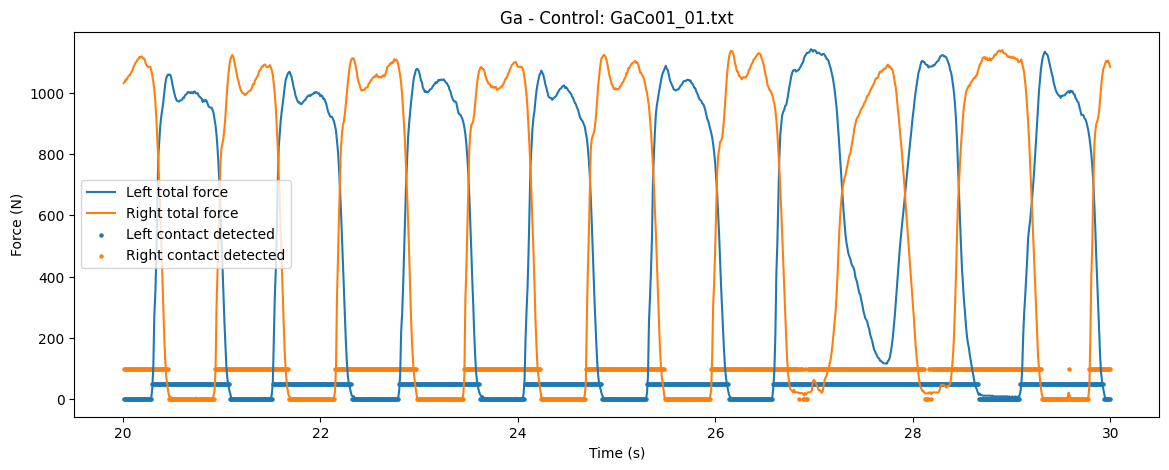

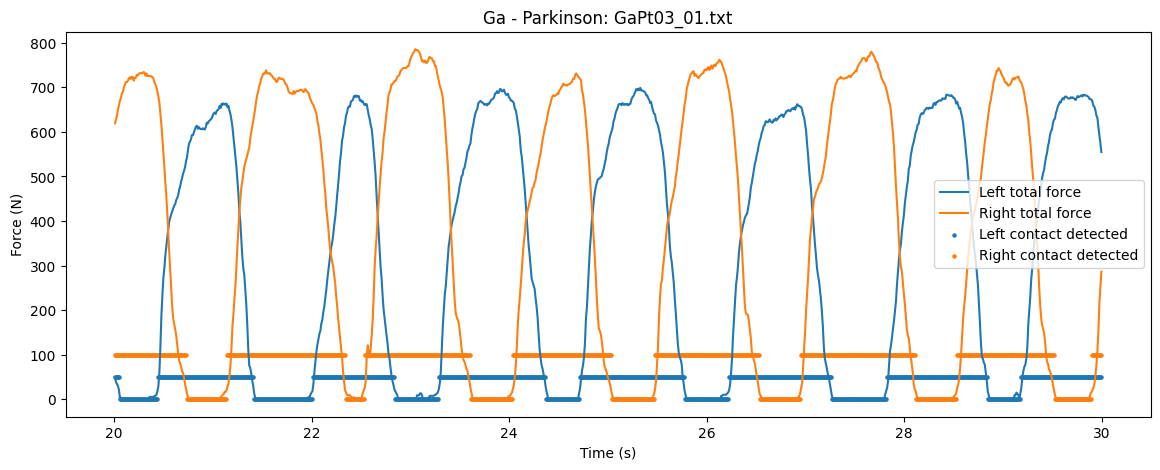

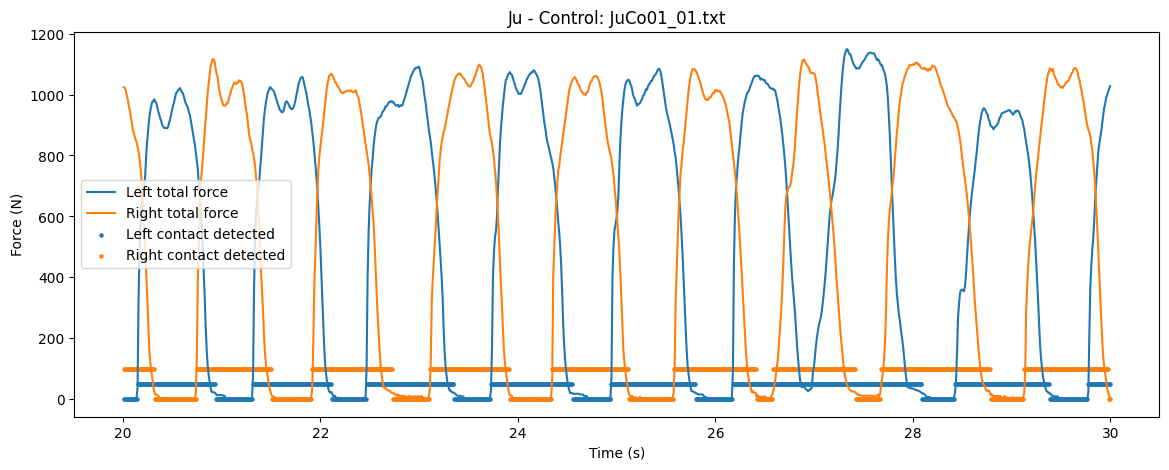

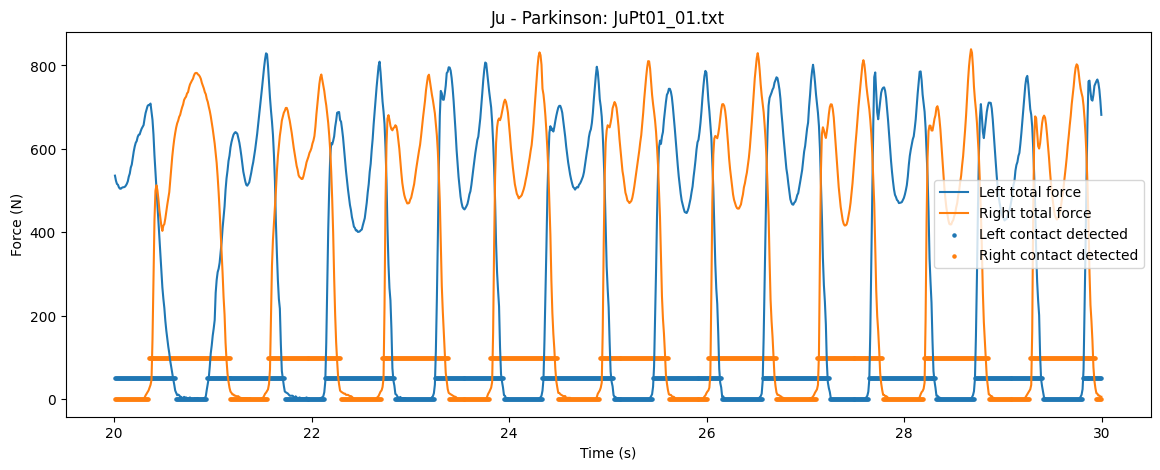

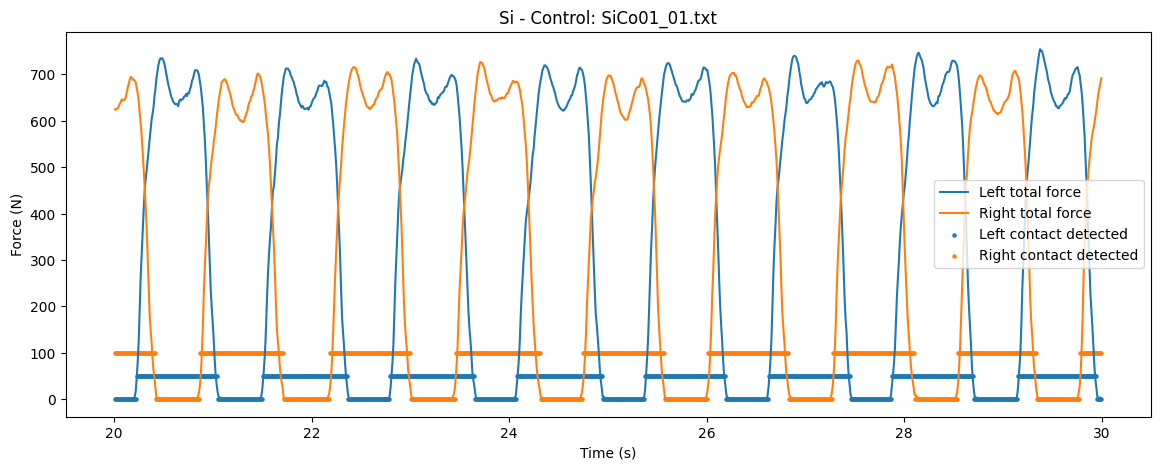

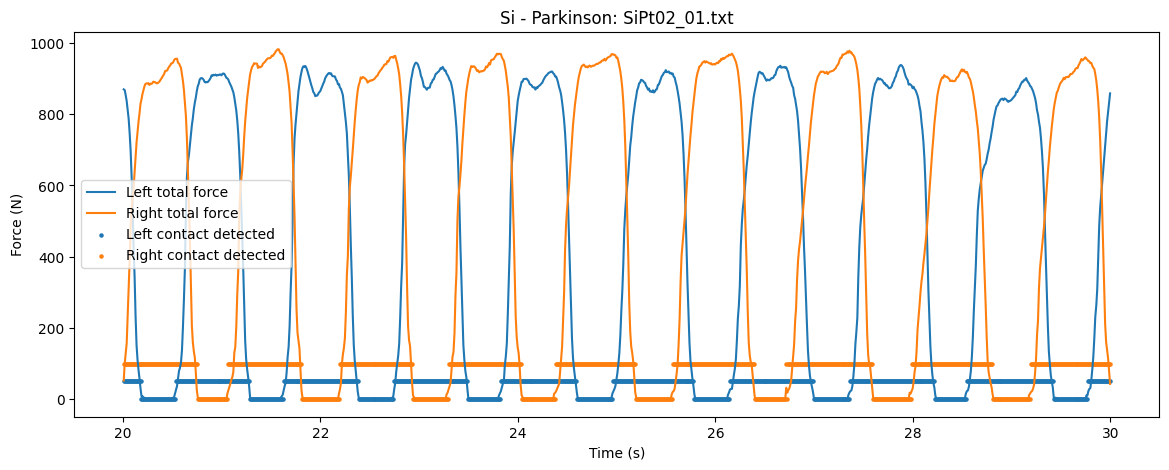

In [24]:
for _, row in example_files.iterrows():
    file_path = Path(row["file_path"])
    
    df = load_gait_signal(file_path)
    df = add_foot_contact_columns(df, threshold=20)
    
    title = f"{row['study']} - {row['group']}: {row['file_name']}"
    
    plot_contact_detection(
        df,
        title=title,
        start_time=20,
        end_time=30
    )

## Threshold check across study groups

The contact detection method was visually checked on one control and one Parkinson recording from each study group: Ga, Ju, and Si.

A fixed threshold of 20 N was used to identify foot contact. In the selected examples, the detected contact periods generally match the visible high-force regions of the signal. This suggests that the threshold-based method is a reasonable starting point for basic foot-contact detection.

However, this method is still simple. It may fail in recordings with noisy signals, unusually low force values, or short contact artifacts. Therefore, later feature extraction should include basic quality checks and filtering of unrealistic contact durations.

In [25]:
example_summaries = []

for _, row in example_files.iterrows():
    file_path = Path(row["file_path"])
    
    df = load_gait_signal(file_path)
    df = add_foot_contact_columns(df, threshold=20)
    
    left_events = detect_contact_events(df, "left_contact")
    right_events = detect_contact_events(df, "right_contact")
    
    left_events_clean = filter_contact_events(left_events)
    right_events_clean = filter_contact_events(right_events)
    
    summary = summarize_contact_events(
        df,
        left_events_clean,
        right_events_clean
    )
    
    summary = add_symmetry_features(summary)
    
    summary["file_name"] = row["file_name"]
    summary["study"] = row["study"]
    summary["group"] = row["group"]
    
    example_summaries.append(summary)

example_summary_table = pd.DataFrame(example_summaries)

example_summary_table

,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,std_left_contact_duration,std_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference,cv_contact_duration_difference,file_name,study,group
0,121.1715,94,98,0.775760,0.808771,0.777711,0.784538,0.070878,0.126962,0.091137,0.161831,4,0.006827,0.070694,GaCo01_01.txt,Ga,Control
1,121.1715,76,80,0.627210,0.660221,1.067432,1.087659,0.134459,0.132125,0.125965,0.121476,4,0.020227,0.004488,GaPt03_01.txt,Ga,Parkinson
2,53.4763,44,45,0.822794,0.841494,0.806309,0.766169,0.179658,0.127664,0.222816,0.166626,1,0.040140,0.056190,JuCo01_01.txt,Ju,Control
3,82.2642,73,72,0.887385,0.875229,0.726526,0.680503,0.162039,0.043659,0.223033,0.064157,1,0.046023,0.158876,JuPt01_01.txt,Ju,Parkinson
4,121.1715,95,95,0.784013,0.784013,0.830151,0.820787,0.122866,0.072824,0.148004,0.088725,0,0.009363,0.059279,SiCo01_01.txt,Si,Control
5,121.1715,108,109,0.891299,0.899551,0.770317,0.757748,0.044550,0.054945,0.057833,0.072511,1,0.012569,0.014678,SiPt02_01.txt,Si,Parkinson


In [26]:
cols = [
    "study",
    "group",
    "file_name",
    "recording_duration_sec",
    "left_contact_count",
    "right_contact_count",
    "left_contacts_per_sec",
    "right_contacts_per_sec",
    "mean_left_contact_duration",
    "mean_right_contact_duration",
    "cv_left_contact_duration",
    "cv_right_contact_duration",
    "contact_count_difference",
    "mean_contact_duration_difference"
]

example_summary_table[cols]

,study,group,file_name,recording_duration_sec,left_contact_count,right_contact_count,left_contacts_per_sec,right_contacts_per_sec,mean_left_contact_duration,mean_right_contact_duration,cv_left_contact_duration,cv_right_contact_duration,contact_count_difference,mean_contact_duration_difference
0,Ga,Control,GaCo01_01.txt,121.1715,94,98,0.775760,0.808771,0.777711,0.784538,0.091137,0.161831,4,0.006827
1,Ga,Parkinson,GaPt03_01.txt,121.1715,76,80,0.627210,0.660221,1.067432,1.087659,0.125965,0.121476,4,0.020227
2,Ju,Control,JuCo01_01.txt,53.4763,44,45,0.822794,0.841494,0.806309,0.766169,0.222816,0.166626,1,0.040140
3,Ju,Parkinson,JuPt01_01.txt,82.2642,73,72,0.887385,0.875229,0.726526,0.680503,0.223033,0.064157,1,0.046023
4,Si,Control,SiCo01_01.txt,121.1715,95,95,0.784013,0.784013,0.830151,0.820787,0.148004,0.088725,0,0.009363
5,Si,Parkinson,SiPt02_01.txt,121.1715,108,109,0.891299,0.899551,0.770317,0.757748,0.057833,0.072511,1,0.012569


In [27]:
example_summary_table.to_csv(
    "../data/processed/six_example_contact_summary.csv",
    index=False
)

The six-example summary shows that basic contact-based measures can be extracted from all selected study groups. These include contact count, contact rate, mean contact duration, contact duration variability, and left-right differences.

At this stage, these values are used mainly to verify that the contact detection pipeline works. Group-level conclusions cannot be made from only six example files. The next step is to apply the same pipeline to all 306 signal files and then compare feature distributions across groups.